In [2]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [5]:
df = pd.read_csv(r"C:\Users\Shagufta\OneDrive\Documents\Data Analyst\Power BI\Dashboard\CCTV\cctv_ecommerce_dataset.csv")

Sentiment Analysis with VADER

For 5 categories: Negative, Mixed Negative, Neutral, Mixed Positive, Positive

In [6]:
sia = SentimentIntensityAnalyzer()

In [7]:
df.columns

Index(['Cust_id', 'Cust_name', 'Cust_age', 'Cust_gender', 'City', 'State',
       'Pin_code', 'Order_id', 'Qty', 'Discount_amt', 'Delivery_fees', 'Total',
       'Order_date', 'Delivery_date', 'Delivery_status', 'Shipping_Partner',
       'Cust_review'],
      dtype='object')

In [8]:
def get_polarity_scores(text):
    return sia.polarity_scores(str(text))['compound']

df['polarity_score'] = df['Cust_review'].apply(get_polarity_scores)

In [9]:
df.sample(5)[['Order_id','polarity_score']]

,Order_id,polarity_score
359,3729,0.6115
3588,7078,0.4404
2406,6933,-0.2960
2281,6494,0.4019
2541,4081,0.6115


In [10]:
print("Max Score", df['polarity_score'].max())
print("Min Score", df['polarity_score'].min())

Max Score 0.8047
Min Score -0.6369


In [11]:
#Generate 5 evenly spaced numbers/bins
import numpy as np
min_score = df['polarity_score'].min()
max_score = df['polarity_score'].max()
bins = np.linspace(min_score, max_score, 6)
bins

array([-0.6369 , -0.34858, -0.06026,  0.22806,  0.51638,  0.8047 ])

In [12]:
def cat_senti(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.6:
        return 'Positive'
    elif 0.2<= score <= 0.6:
        return 'Mixed Positive'
    elif -0.2<= score <= 0.2:
        return 'Neutral'
    elif -0.2<= score <= 0.6:
        return 'Mixed Negative'
    else:
        return 'Negative'

df['Sentiment'] = df['Cust_review'].apply(cat_senti)

In [13]:
df.sample(5)[['Order_id','Cust_review','Sentiment']]

,Order_id,Cust_review,Sentiment
1192,7016,Appreciate the quick response and delivery.,Mixed Positive
1074,6923,Good packaging and timely delivery.,Mixed Positive
2273,6312,Delivered quicker than expected. Impressed!,Mixed Positive
2764,4702,Good packaging and timely delivery.,Mixed Positive
3584,6862,"Product as described, no issues at all.",Negative


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
sent2 = df.groupby(['Sentiment']).size().reset_index(name='Count').sort_values(by='Count', ascending=False)
sent2

,Sentiment,Count
0,Mixed Positive,2209
3,Positive,1438
1,Negative,365
2,Neutral,344


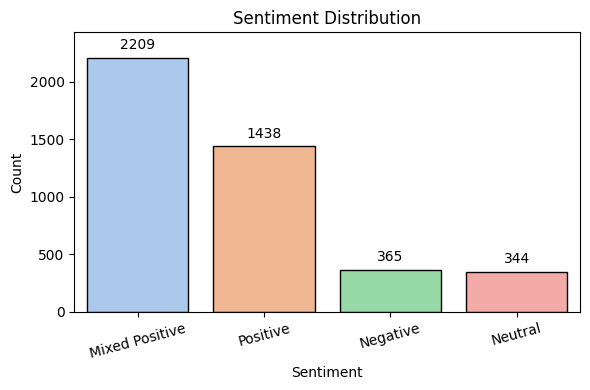

In [17]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(6,4)) 
ax = sns.barplot(data=sent2, x='Sentiment', y='Count', palette='pastel', edgecolor='black')

plt.xticks(rotation=15, ha='center')


for bars in ax.containers:
    ax.bar_label(bars, padding=4)

plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')

max_count = sent2['Count'].max()
plt.ylim(0, max_count + max_count * 0.1)

plt.tight_layout()
plt.show()

In [19]:
df[['Order_id', 'Cust_review','Sentiment']].to_csv('Customer_Feedback_Analysis.csv', index =False)